<a href="https://colab.research.google.com/github/Maksura-123/project-/blob/main/25549910032_Lab_assignmment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np

# Define key system parameters
num_users = 4  # Number of users in the CDMA system
spreading_factor = 16 # Spreading factor (chips per bit)
num_bits = 1000 # Number of bits each user will transmit (simulation duration or data length)

print(f"Number of users: {num_users}")
print(f"Spreading factor: {spreading_factor}")
print(f"Number of bits per user: {num_bits}")

Number of users: 4
Spreading factor: 16
Number of bits per user: 1000


In [10]:
from scipy.linalg import hadamard

# Generate Hadamard matrix
hadamard_matrix = hadamard(spreading_factor)

# Select the first num_users rows as PN sequences
pn_sequences = hadamard_matrix[:num_users, :]

print(f"Generated {num_users} PN sequences, each of length {spreading_factor}.")
print("First PN sequence example:\n", pn_sequences[0])

Generated 4 PN sequences, each of length 16.
First PN sequence example:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [11]:
user_data = [] # Initialize an empty list to store user data

for i in range(num_users):
    # Generate random binary data (0s and 1s) for the current user
    binary_data = np.random.randint(0, 2, num_bits)

    # Convert binary data to BPSK symbols (-1 for 0, 1 for 1)
    bpsk_data = 2 * binary_data - 1

    # Append the BPSK-modulated data for the current user
    user_data.append(bpsk_data)

print(f"Generated user data for {num_users} users, each with {num_bits} bits (BPSK symbols).")
print(f"First user's first 10 BPSK symbols: {user_data[0][:10]}")

Generated user data for 4 users, each with 1000 bits (BPSK symbols).
First user's first 10 BPSK symbols: [-1  1  1 -1 -1  1 -1  1 -1 -1]


In [12]:
spread_signals = [] # Initialize an empty list to store the spread data for each user

for i in range(num_users):
    # Get the BPSK-modulated data for the current user
    current_user_bpsk_data = user_data[i]

    # Get the PN sequence for the current user
    current_user_pn_sequence = pn_sequences[i]

    # Reshape the BPSK-modulated data for element-wise multiplication
    # Each bit will be multiplied by the entire PN sequence
    reshaped_bpsk_data = current_user_bpsk_data.reshape(-1, 1) # Reshape to (num_bits, 1)

    # Perform spreading by multiplying the reshaped BPSK data with the PN sequence
    # The result for each bit is a vector of length spreading_factor
    spread_data_matrix = reshaped_bpsk_data * current_user_pn_sequence

    # Flatten the spread data for the current user into a 1D array
    flattened_spread_data = spread_data_matrix.flatten()

    # Append the flattened spread data to the list
    spread_signals.append(flattened_spread_data)

print(f"Generated spread signals for {num_users} users.")
print(f"Length of the first user's spread signal: {len(spread_signals[0])} chips")
print(f"First user's first {spreading_factor*2} chips:\n{spread_signals[0][:spreading_factor*2]}")

Generated spread signals for 4 users.
Length of the first user's spread signal: 16000 chips
First user's first 32 chips:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


In [13]:
import numpy as np

# Convert the list of spread signals to a NumPy array
spread_signals_array = np.array(spread_signals)

# Sum all the spread signals to create the combined signal
# The sum is performed along axis 0, combining all users' signals chip by chip
combined_signal = np.sum(spread_signals_array, axis=0)

print(f"Shape of the combined signal: {combined_signal.shape}")
print(f"First 32 chips of the combined signal:\n{combined_signal[:32]}")

Shape of the combined signal: (16000,)
First 32 chips of the combined signal:
[-2  2 -2 -2 -2  2 -2 -2 -2  2 -2 -2 -2  2 -2 -2  2 -2  2  2  2 -2  2  2
  2 -2  2  2  2 -2  2  2]


In [14]:
import numpy as np

# 1. Select a target user ID
target_user_id = 0 # Example: demodulate data for the first user

# 2. Retrieve the PN sequence for the target user
target_user_pn_sequence = pn_sequences[target_user_id]

# 3. Multiply the combined_signal with the target user's PN sequence
# Tile the PN sequence to match the length of the combined signal
tiled_pn_sequence = np.tile(target_user_pn_sequence, num_bits)

despreadded_signal = combined_signal * tiled_pn_sequence

# 4. Reshape the resulting signal into segments corresponding to the spreading_factor
# Each segment corresponds to one bit's worth of spread signal
reshaped_despreadded_signal = despreadded_signal.reshape(num_bits, spreading_factor)

# 5. For each segment, sum the chips to perform the despreading
# This effectively integrates the signal over one bit period
summed_despreadded_signal = np.sum(reshaped_despreadded_signal, axis=1)

# 6. Apply a decision rule (sign function) to convert the despread values back to BPSK symbols
# Positive sum -> 1, Negative sum -> -1
recovered_data = np.sign(summed_despreadded_signal)

# Ensure recovered_data contains only -1 or 1, not 0 if a sum was exactly zero
recovered_data[recovered_data == 0] = 1 # Arbitrarily assign 1 for 0 sum

# 7. Compare the recovered data with the original user_data to calculate the Bit Error Rate (BER)
original_data = user_data[target_user_id]

# Count mismatches (errors)
errors = np.sum(original_data != recovered_data)

# Calculate BER
ber = errors / num_bits

# 8. Print the first 10 original BPSK symbols, the first 10 recovered BPSK symbols, and the calculated BER
print(f"Target user ID for demodulation: {target_user_id}")
print(f"Original data (first 10 BPSK symbols): {original_data[:10]}")
print(f"Recovered data (first 10 BPSK symbols): {recovered_data[:10]}")
print(f"Bit Error Rate (BER) for user {target_user_id}: {ber:.4f}")

Target user ID for demodulation: 0
Original data (first 10 BPSK symbols): [-1  1  1 -1 -1  1 -1  1 -1 -1]
Recovered data (first 10 BPSK symbols): [-1  1  1 -1 -1  1 -1  1 -1 -1]
Bit Error Rate (BER) for user 0: 0.0000


In [15]:
snr_db_range = np.arange(0, 11, 2) # SNR levels from 0 to 10 dB in steps of 2
jammer_power_db_range = np.array([0, 5, 10]) # Jammer power levels in dB

narrowband_jammer_frequency = 0.1 # Normalized frequency for narrowband jammer
broadband_jammer_type = 'AWGN' # Type for broadband jammer

print(f"SNR range (dB): {snr_db_range}")
print(f"Jammer power range (dB): {jammer_power_db_range}")
print(f"Narrowband jammer frequency: {narrowband_jammer_frequency}")
print(f"Broadband jammer type: {broadband_jammer_type}")

SNR range (dB): [ 0  2  4  6  8 10]
Jammer power range (dB): [ 0  5 10]
Narrowband jammer frequency: 0.1
Broadband jammer type: AWGN


In [16]:
impaired_signals_awgn = {} # Initialize dictionary to store impaired signals with AWGN

for snr_db in snr_db_range:
    # Convert SNR from dB to linear scale
    snr_linear = 10**(snr_db / 10)

    # Calculate signal power (average power of the combined signal)
    signal_power = np.mean(combined_signal**2)

    # Calculate noise power (variance)
    # The formula for SNR is P_signal / P_noise, so P_noise = P_signal / SNR
    noise_power = signal_power / snr_linear

    # Generate Additive White Gaussian Noise (AWGN)
    # np.random.normal(mean, standard_deviation, size)
    # standard_deviation = sqrt(variance) = sqrt(noise_power)
    awgn = np.random.normal(0, np.sqrt(noise_power), combined_signal.shape)

    # Add AWGN to the combined signal
    combined_signal_with_awgn = combined_signal + awgn

    # Store the impaired signal in the dictionary
    impaired_signals_awgn[snr_db] = combined_signal_with_awgn

print("AWGN has been added to the combined signal for all specified SNR levels.")
print(f"Number of impaired signals generated: {len(impaired_signals_awgn)}")
print(f"Shape of signal at SNR {snr_db_range[0]} dB: {impaired_signals_awgn[snr_db_range[0]].shape}")

AWGN has been added to the combined signal for all specified SNR levels.
Number of impaired signals generated: 6
Shape of signal at SNR 0 dB: (16000,)


In [17]:
narrowband_jammers = {} # Initialize dictionary to store generated narrowband jammer signals

for jammer_power_db in jammer_power_db_range:
    # Convert jammer power from dB to linear scale
    jammer_power_linear = 10**(jammer_power_db / 10)

    # Calculate signal power of the combined signal
    signal_power = np.mean(combined_signal**2)

    # Determine the amplitude of the narrowband jammer
    # Ensure jammer power is relative to the signal power. For a sinusoidal signal, P = A^2/2
    # If we want the jammer_power_linear to represent the ratio of jammer power to signal power,
    # then jammer_power = jammer_power_linear * signal_power
    # For a sine wave, power is Amplitude^2 / 2. So A = sqrt(2 * power)
    # However, the instruction suggests np.sqrt(jammer_power_linear * signal_power) which implies
    # that jammer_power_linear is already the jammer-to-signal power ratio (J/S).
    # Let's stick to the instruction: A = sqrt(J/S * P_signal)
    amplitude = np.sqrt(jammer_power_linear * signal_power)

    # Generate a time vector
    t = np.arange(0, len(combined_signal)) # Time vector from 0 to length of combined_signal - 1

    # Create the sinusoidal narrowband jammer signal
    # The frequency 'narrowband_jammer_frequency' is normalized (0 to 0.5 for Nyquist criterion)
    # Assuming sampling rate is 1 (normalized), so 2*pi*f*t
    narrowband_jammer_signal = amplitude * np.sin(2 * np.pi * narrowband_jammer_frequency * t)

    # Store the generated jammer signal in the dictionary
    narrowband_jammers[jammer_power_db] = narrowband_jammer_signal

print("Narrowband jammers generated for all specified power levels.")
print(f"Number of narrowband jammer signals generated: {len(narrowband_jammers)}")
print(f"Shape of jammer signal at {jammer_power_db_range[0]} dB: {narrowband_jammers[jammer_power_db_range[0]].shape}")

Narrowband jammers generated for all specified power levels.
Number of narrowband jammer signals generated: 3
Shape of jammer signal at 0 dB: (16000,)


In [18]:
broadband_jammers = {} # Initialize dictionary to store generated broadband jammer signals

for jammer_power_db in jammer_power_db_range:
    # Convert jammer power from dB to linear scale
    jammer_power_linear = 10**(jammer_power_db / 10)

    # Calculate signal power of the combined signal
    signal_power = np.mean(combined_signal**2)

    # Calculate jammer noise power relative to signal power
    # For broadband AWGN jammer, its power is its variance.
    # We want J/S = jammer_power_linear
    # So, jammer_power_awgn = jammer_power_linear * signal_power
    jammer_power_awgn = jammer_power_linear * signal_power

    # Generate broadband AWGN jammer signal
    # standard_deviation = sqrt(variance) = sqrt(jammer_power_awgn)
    broadband_jammer_signal = np.random.normal(0, np.sqrt(jammer_power_awgn), combined_signal.shape)

    # Store the generated jammer signal in the dictionary
    broadband_jammers[jammer_power_db] = broadband_jammer_signal

print("Broadband jammers generated for all specified power levels.")
print(f"Number of broadband jammer signals generated: {len(broadband_jammers)}")
print(f"Shape of jammer signal at {jammer_power_db_range[0]} dB: {broadband_jammers[jammer_power_db_range[0]].shape}")

Broadband jammers generated for all specified power levels.
Number of broadband jammer signals generated: 3
Shape of jammer signal at 0 dB: (16000,)


In [19]:
impaired_signals_combined = {}

# Iterate through each SNR level where AWGN has already been added
for snr_db in snr_db_range:
    # Get the signal with AWGN for the current SNR level
    signal_with_awgn = impaired_signals_awgn[snr_db]

    impaired_signals_combined[snr_db] = {} # Create a nested dictionary for jammer power levels

    # Iterate through each jammer power level
    for jammer_power_db in jammer_power_db_range:
        # Get the corresponding narrowband jammer signal
        nb_jammer = narrowband_jammers[jammer_power_db]

        # Get the corresponding broadband jammer signal
        bb_jammer = broadband_jammers[jammer_power_db]

        # Combine the AWGN-impaired signal with both jammers
        fully_impaired_signal = signal_with_awgn + nb_jammer + bb_jammer

        # Store the fully impaired signal in the nested dictionary
        impaired_signals_combined[snr_db][jammer_power_db] = fully_impaired_signal

print("Combined impaired signals generated for all SNR and jammer power combinations.")
print(f"Total number of combined impaired signals (SNR x Jammer Power): {len(impaired_signals_combined) * len(jammer_power_db_range)}")
print(f"Example shape at SNR {snr_db_range[0]} dB, Jammer Power {jammer_power_db_range[0]} dB: {impaired_signals_combined[snr_db_range[0]][jammer_power_db_range[0]].shape}")

Combined impaired signals generated for all SNR and jammer power combinations.
Total number of combined impaired signals (SNR x Jammer Power): 18
Example shape at SNR 0 dB, Jammer Power 0 dB: (16000,)


In [20]:
ber_results = {} # Initialize dictionary to store BER results for all combinations

# Target user's original data for comparison
original_data = user_data[target_user_id]

# Retrieve the PN sequence for the target user (already done in previous cell, but for clarity)
target_user_pn_sequence = pn_sequences[target_user_id]

# Pre-tile the PN sequence once for efficiency if possible, or tile inside loop
# It needs to be tiled for each combined signal, which has num_bits * spreading_factor length.
# This is done inside the loop as combined_signal length is consistent.

# Iterate through each SNR level
for snr_db in snr_db_range:
    ber_results[snr_db] = {} # Nested dictionary for jammer power levels

    # Iterate through each jammer power level
    for jammer_power_db in jammer_power_db_range:
        # Get the fully impaired signal for the current SNR and jammer power combination
        fully_impaired_signal = impaired_signals_combined[snr_db][jammer_power_db]

        # 1. Tile the PN sequence to match the length of the fully impaired signal
        tiled_pn_sequence = np.tile(target_user_pn_sequence, num_bits)

        # 2. Multiply the fully impaired signal with the target user's PN sequence (despreading)
        despreadded_signal = fully_impaired_signal * tiled_pn_sequence

        # 3. Reshape the resulting signal into segments corresponding to the spreading_factor
        reshaped_despreadded_signal = despreadded_signal.reshape(num_bits, spreading_factor)

        # 4. For each segment, sum the chips to perform the despreading (integrate over bit period)
        summed_despreadded_signal = np.sum(reshaped_despreadded_signal, axis=1)

        # 5. Apply a decision rule (sign function) to convert despread values back to BPSK symbols
        recovered_data = np.sign(summed_despreadded_signal)

        # Ensure recovered_data contains only -1 or 1, not 0 if a sum was exactly zero
        recovered_data[recovered_data == 0] = 1 # Arbitrarily assign 1 for 0 sum

        # 6. Calculate Bit Error Rate (BER)
        errors = np.sum(original_data != recovered_data)
        ber = errors / num_bits

        # Store the calculated BER
        ber_results[snr_db][jammer_power_db] = ber

print(f"Demodulation and despreading complete for target user {target_user_id}.")
print("BER results across different SNR and jammer power levels:")
for snr, jammer_bers in ber_results.items():
    print(f"  SNR {snr} dB:")
    for jammer_power, ber_value in jammer_bers.items():
        print(f"    Jammer Power {jammer_power} dB: {ber_value:.4f}")

Demodulation and despreading complete for target user 0.
BER results across different SNR and jammer power levels:
  SNR 0 dB:
    Jammer Power 0 dB: 0.0880
    Jammer Power 5 dB: 0.2080
    Jammer Power 10 dB: 0.2990
  SNR 2 dB:
    Jammer Power 0 dB: 0.0840
    Jammer Power 5 dB: 0.1900
    Jammer Power 10 dB: 0.2910
  SNR 4 dB:
    Jammer Power 0 dB: 0.0620
    Jammer Power 5 dB: 0.1830
    Jammer Power 10 dB: 0.2920
  SNR 6 dB:
    Jammer Power 0 dB: 0.0510
    Jammer Power 5 dB: 0.1840
    Jammer Power 10 dB: 0.2830
  SNR 8 dB:
    Jammer Power 0 dB: 0.0530
    Jammer Power 5 dB: 0.1590
    Jammer Power 10 dB: 0.2760
  SNR 10 dB:
    Jammer Power 0 dB: 0.0510
    Jammer Power 5 dB: 0.1620
    Jammer Power 10 dB: 0.2850


In [29]:
ber_results_user1 = {} # Initialize dictionary to store BER results for user 1

# Set target user ID to 1
target_user_id_for_analysis = 1

# Target user's original data for comparison
original_data_user1 = user_data[target_user_id_for_analysis]

# Retrieve the PN sequence for the target user
target_user_pn_sequence_user1 = pn_sequences[target_user_id_for_analysis]

# Iterate through each SNR level
for snr_db in snr_db_range:
    ber_results_user1[snr_db] = {} # Nested dictionary for jammer power levels

    # Iterate through each jammer power level
    for jammer_power_db in jammer_power_db_range:
        # Get the fully impaired signal for the current SNR and jammer power combination
        fully_impaired_signal = impaired_signals_combined[snr_db][jammer_power_db]

        # 1. Tile the PN sequence to match the length of the fully impaired signal
        tiled_pn_sequence = np.tile(target_user_pn_sequence_user1, num_bits)

        # 2. Multiply the fully impaired signal with the target user's PN sequence (despreading)
        despreadded_signal = fully_impaired_signal * tiled_pn_sequence

        # 3. Reshape the resulting signal into segments corresponding to the spreading_factor
        reshaped_despreadded_signal = despreadded_signal.reshape(num_bits, spreading_factor)

        # 4. For each segment, sum the chips to perform the despreading (integrate over bit period)
        summed_despreadded_signal = np.sum(reshaped_despreadded_signal, axis=1)

        # 5. Apply a decision rule (sign function) to convert despread values back to BPSK symbols
        recovered_data = np.sign(summed_despreadded_signal)

        # Ensure recovered_data contains only -1 or 1, not 0 if a sum was exactly zero
        recovered_data[recovered_data == 0] = 1 # Arbitrarily assign 1 for 0 sum

        # 6. Calculate Bit Error Rate (BER)
        errors = np.sum(original_data_user1 != recovered_data)
        ber = errors / num_bits

        # Store the calculated BER
        ber_results_user1[snr_db][jammer_power_db] = ber

print(f"Demodulation and despreading complete for target user {target_user_id_for_analysis}.")
print("BER results across different SNR and jammer power levels for user 1:")
for snr, jammer_bers in ber_results_user1.items():
    print(f"  SNR {snr} dB:")
    for jammer_power, ber_value in jammer_bers.items():
        print(f"    Jammer Power {jammer_power} dB: {ber_value:.4f}")

Demodulation and despreading complete for target user 1.
BER results across different SNR and jammer power levels for user 1:
  SNR 0 dB:
    Jammer Power 0 dB: 0.0640
    Jammer Power 5 dB: 0.1590
    Jammer Power 10 dB: 0.2720
  SNR 2 dB:
    Jammer Power 0 dB: 0.0540
    Jammer Power 5 dB: 0.1300
    Jammer Power 10 dB: 0.2740
  SNR 4 dB:
    Jammer Power 0 dB: 0.0440
    Jammer Power 5 dB: 0.1350
    Jammer Power 10 dB: 0.2560
  SNR 6 dB:
    Jammer Power 0 dB: 0.0360
    Jammer Power 5 dB: 0.1180
    Jammer Power 10 dB: 0.2670
  SNR 8 dB:
    Jammer Power 0 dB: 0.0320
    Jammer Power 5 dB: 0.1210
    Jammer Power 10 dB: 0.2750
  SNR 10 dB:
    Jammer Power 0 dB: 0.0270
    Jammer Power 5 dB: 0.1170
    Jammer Power 10 dB: 0.2710


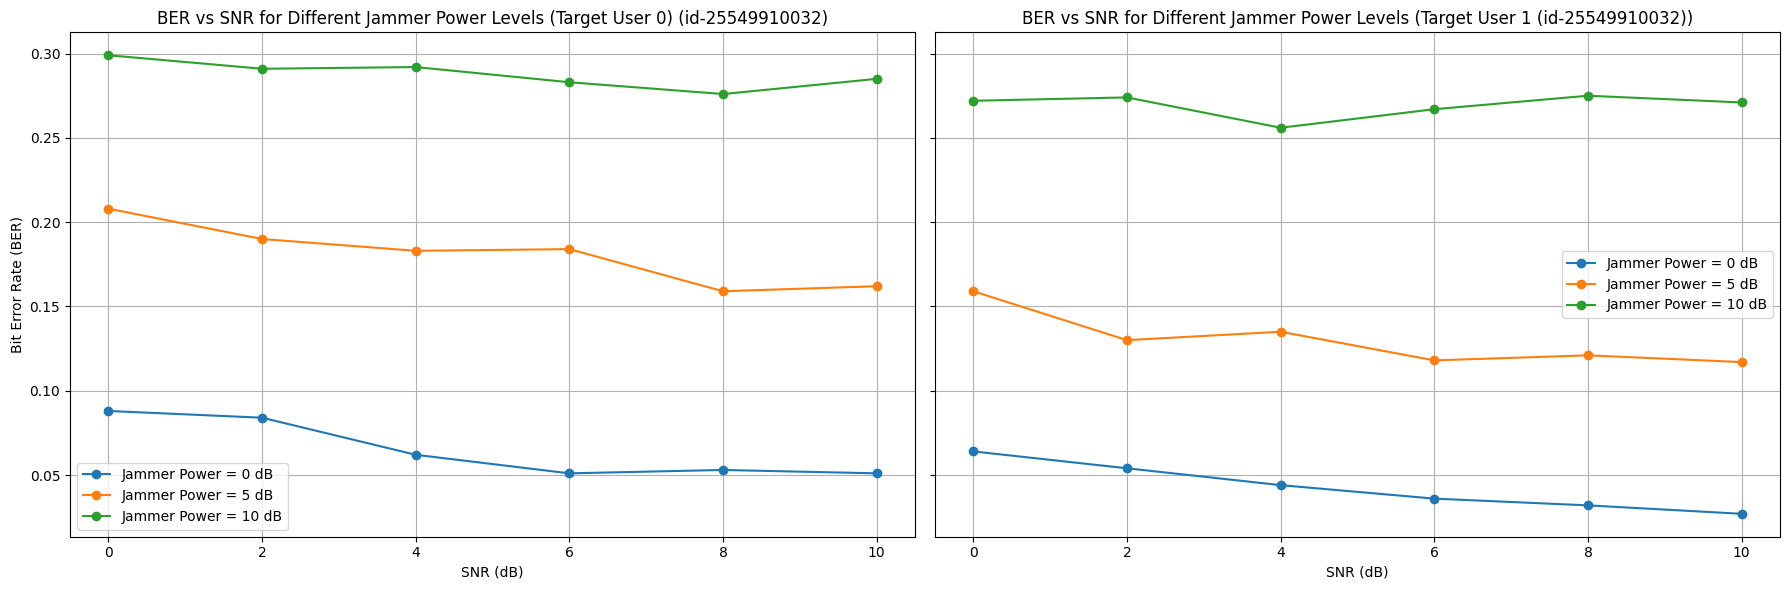

In [30]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# --- Plot for User 0 (Left Subplot) ---
for jammer_power_db in jammer_power_db_range:
    bers_for_current_jammer_user0 = [ber_results[snr_db][jammer_power_db] for snr_db in snr_db_range]
    axes[0].plot(snr_db_range, bers_for_current_jammer_user0, marker='o', label=f'Jammer Power = {jammer_power_db} dB')

axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Bit Error Rate (BER)')
axes[0].set_title(f'BER vs SNR for Different Jammer Power Levels (Target User {target_user_id}) (id-25549910032)')
axes[0].legend()
axes[0].grid(True)

# --- Plot for User 1 (Right Subplot) ---
for jammer_power_db in jammer_power_db_range:
    bers_for_current_jammer_user1 = [ber_results_user1[snr_db][jammer_power_db] for snr_db in snr_db_range]
    axes[1].plot(snr_db_range, bers_for_current_jammer_user1, marker='o', label=f'Jammer Power = {jammer_power_db} dB')

axes[1].set_xlabel('SNR (dB)')
axes[1].set_title(f'BER vs SNR for Different Jammer Power Levels (Target User {target_user_id_for_analysis} (id-25549910032))')
axes[1].legend()
axes[1].grid(True)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plots
plt.show()

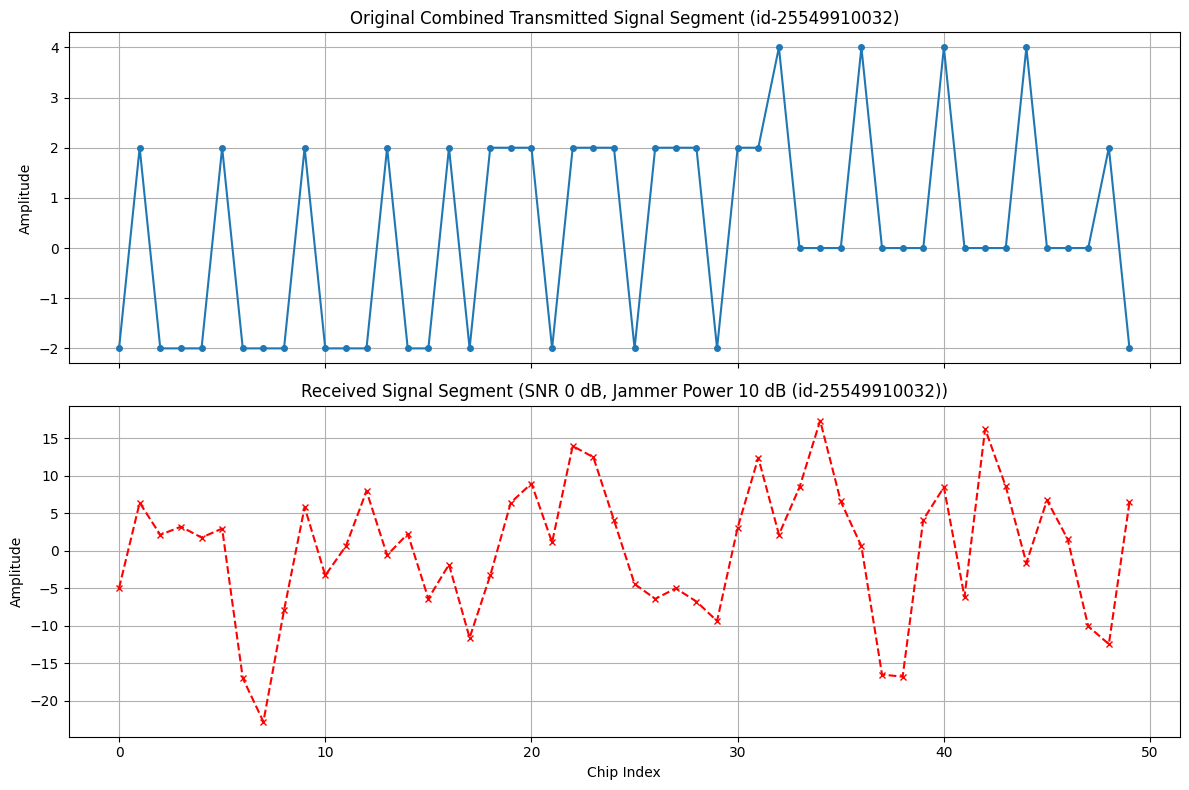

In [31]:
import matplotlib.pyplot as plt

# 1. Choose an arbitrary, short segment length and a starting index
start_index = 0
segment_length = 50

# 2. Select specific impairment conditions for the received signal
selected_snr_db = snr_db_range[0] # Example: lowest SNR (0 dB)
selected_jammer_power_db = jammer_power_db_range[-1] # Example: highest jammer power (10 dB)

# 3. Extract the chosen segment from the combined_signal
transmitted_segment = combined_signal[start_index : start_index + segment_length]

# 4. Retrieve the fully impaired signal and extract the same segment
fully_impaired_signal = impaired_signals_combined[selected_snr_db][selected_jammer_power_db]
received_segment = fully_impaired_signal[start_index : start_index + segment_length]

# 5. Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 6. Plot the transmitted_segment on the first subplot
axes[0].plot(transmitted_segment, marker='o', linestyle='-', markersize=4)
axes[0].set_title('Original Combined Transmitted Signal Segment (id-25549910032)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# 7. Plot the received_segment on the second subplot
axes[1].plot(received_segment, marker='x', linestyle='--', markersize=4, color='red')
axes[1].set_title(f'Received Signal Segment (SNR {selected_snr_db} dB, Jammer Power {selected_jammer_power_db} dB (id-25549910032))')
axes[1].set_xlabel('Chip Index')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)

# 8. Use plt.tight_layout() to prevent titles/labels from overlapping
plt.tight_layout()

# 9. Display the plots
plt.show()